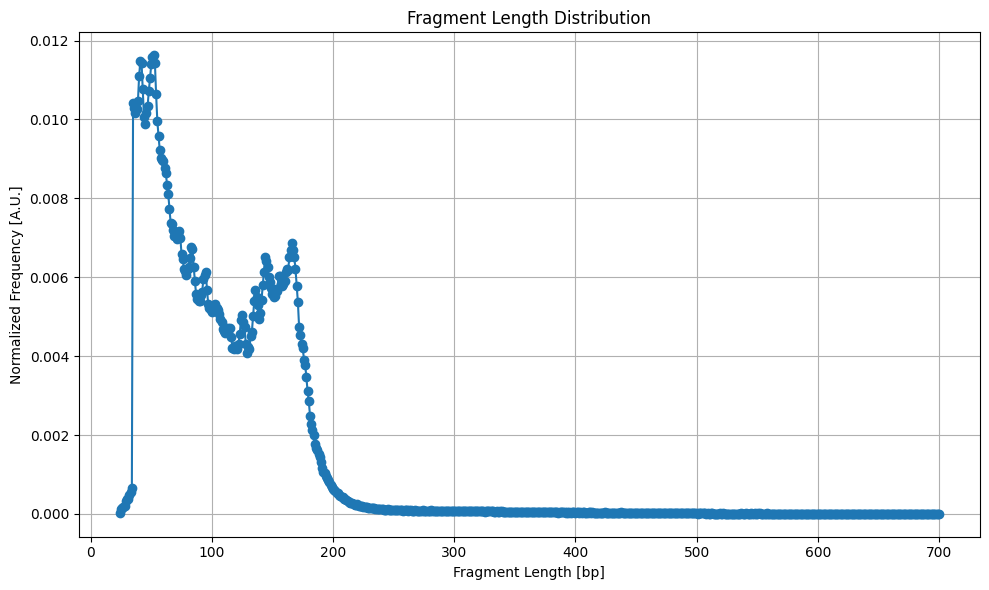

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import gzip

# Define the file path
file_path = "query.bed.gz"  # Replace with your actual file path if different

# Read the gzipped BED file
with gzip.open(file_path, 'rt') as f:
    df = pd.read_csv(f, sep='\t', header=None, usecols=[1, 2], names=['start', 'end'])

# Calculate fragment lengths
df['length'] = df['end'] - df['start']

# Count the frequency of each fragment length
length_counts = df['length'].value_counts().sort_index()

# Normalize the frequencies
normalized_counts = length_counts / length_counts.sum()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(normalized_counts.index, normalized_counts.values, marker='o', linestyle='-')
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()


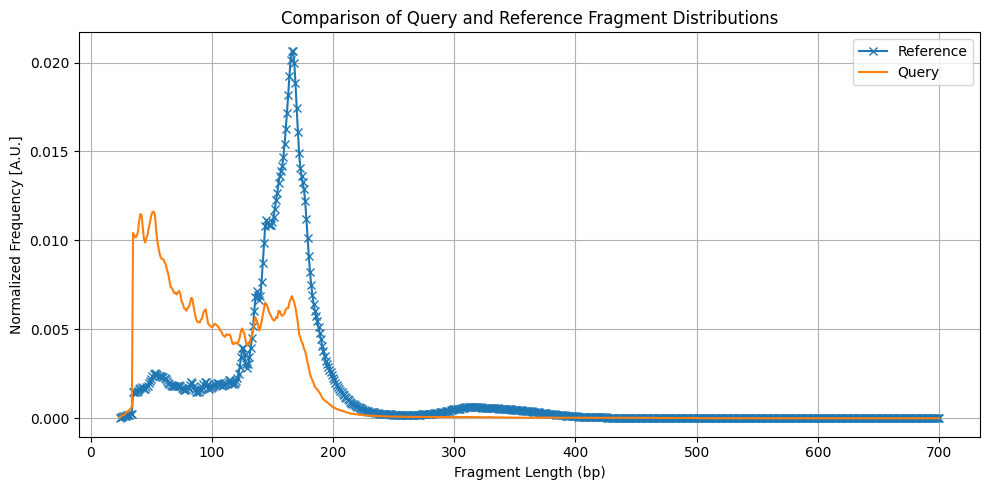

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load reference.hist file
ref_path = 'reference.hist'  # Update if needed
ref = pd.read_csv(ref_path, sep="\t", header=None, comment="#")
ref.columns = ['Length', 'Count']

# Normalize reference frequencies
ref_total = ref['Count'].sum()
ref['Normalized'] = ref['Count'] / ref_total

# Step 2: Prepare query data from previous code
# Assuming `normalized_freq` is already defined
sorted_query = sorted(normalized_counts.items())
query_lengths, query_norm = zip(*sorted_query)

# Step 3: Plot reference vs query distributions
plt.figure(figsize=(10, 5))

# Reference line with cross markers
plt.plot(ref['Length'], ref['Normalized'], label='Reference', color='tab:blue', marker='x')

# Query line without marker
plt.plot(query_lengths, query_norm, label='Query', color='tab:orange')

plt.legend()
plt.title("Comparison of Query and Reference Fragment Distributions")
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.grid(True)
plt.tight_layout()
plt.show()